In [32]:
from pathlib import Path

# Detecta bien la ruta tanto si ejecutas desde raíz como desde /src
TRAIN_DIR = Path("data/raw/train")
TEST_DIR  = Path("data/raw/test")

if not TRAIN_DIR.exists():
    TRAIN_DIR = Path("../data/raw/train")
if not TEST_DIR.exists():
    TEST_DIR = Path("../data/raw/test")

print("TRAIN_DIR:", TRAIN_DIR.resolve())
print("TEST_DIR :", TEST_DIR.resolve())

def count_images(folder: Path):
    if not folder.exists():
        return 0
    return len(list(folder.glob("*.jpg")))

for split_dir, name in [(TRAIN_DIR, "train"), (TEST_DIR, "test")]:
    print(f"\n{name.upper()}:")
    print("  cats:", count_images(split_dir/"cat"))
    print("  dogs:", count_images(split_dir/"dog"))


TRAIN_DIR: /workspaces/dori1888-intro-ml/data/raw/train
TEST_DIR : /workspaces/dori1888-intro-ml/data/raw/test

TRAIN:
  cats: 10000
  dogs: 10000

TEST:
  cats: 2500
  dogs: 2500


In [33]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ===============================
# RUTAS (auto-detectadas)
# ===============================
TRAIN_DIR = Path("data/raw/train")
TEST_DIR = Path("data/raw/test")

if not TRAIN_DIR.exists():
    TRAIN_DIR = Path("../data/raw/train")
if not TEST_DIR.exists():
    TEST_DIR = Path("../data/raw/test")

print("✅ TRAIN_DIR:", TRAIN_DIR)
print("✅ TEST_DIR :", TEST_DIR)

# ===============================
# CONFIG
# ===============================
IMG_SIZE = (200, 200)
BATCH_SIZE = 8

# ===============================
# GENERADORES TRAIN / VAL
# ===============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Clases:", train_data.class_indices)


✅ TRAIN_DIR: ../data/raw/train
✅ TEST_DIR : ../data/raw/test


Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Clases: {'cat': 0, 'dog': 1}


In [34]:
from pathlib import Path

print("CWD (dónde está corriendo el notebook):", Path().resolve())
print("\nExiste models/?", Path("models").exists())

print("\nContenido de models/:")
if Path("models").exists():
    for p in sorted(Path("models").glob("*")):
        print(" -", p, " | size:", p.stat().st_size)
else:
    print("No existe la carpeta models/ en este nivel.")

print("\nBuscando best_model.keras en todo el proyecto (hasta 4 niveles):")
for p in sorted(Path(".").glob("**/best_model.keras")):
    print("FOUND:", p.resolve())


CWD (dónde está corriendo el notebook): /workspaces/dori1888-intro-ml/src

Existe models/? True

Contenido de models/:
 - models/arima_sales.pkl  | size: 2314847
 - models/kmeans_6clusters.pkl  | size: 67721
 - models/rf_cluster_classifier.pkl  | size: 29632265

Buscando best_model.keras en todo el proyecto (hasta 4 niveles):


In [35]:
from pathlib import Path

root = Path("..")  # desde /src, esto apunta a la raíz del repo
kfiles = list(root.rglob("*.keras"))

print("Encontrados .keras:", len(kfiles))
for p in kfiles[:20]:
    print("-", p.resolve())


Encontrados .keras: 2
- /workspaces/dori1888-intro-ml/models/best_model.keras
- /workspaces/dori1888-intro-ml/models/final_model.keras


In [36]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

MODEL_PATH = Path("../models/best_model.keras")
TEST_DIR = Path("../data/raw/test")

model = tf.keras.models.load_model(MODEL_PATH)

# Detectar tamaño esperado por el modelo (altura, ancho)
input_shape = model.input_shape  # (None, H, W, C)
H, W = input_shape[1], input_shape[2]
print("✅ Modelo espera imágenes de:", (H, W), "canales:", input_shape[3])

BATCH_SIZE = 8

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(H, W),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


✅ Modelo espera imágenes de: (160, 160) canales: 3
Found 5000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


In [37]:
model = tf.keras.models.load_model("../models/best_model.keras")

loss, acc = model.evaluate(test_data, verbose=1)
print(acc)


625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7908 - loss: 0.6405
0.7907999753952026


In [38]:
import os
print(os.getcwd())
print(os.path.exists("../models/best_model.keras"))


/workspaces/dori1888-intro-ml/src
True


In [39]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths (porque tu notebook corre en /src)
MODEL_PATH = Path("../models/best_model.keras")
TEST_DIR   = Path("../data/raw/test")

print("📍 CWD:", Path().resolve())
print("✅ Modelo existe:", MODEL_PATH.exists(), "->", MODEL_PATH.resolve())
print("✅ Test dir existe:", TEST_DIR.exists(), "->", TEST_DIR.resolve())

# Cargar modelo
model = tf.keras.models.load_model(MODEL_PATH)

# 🔑 Toma el tamaño real que espera el modelo (evita el error típico)
img_h, img_w = model.input_shape[1], model.input_shape[2]
IMG_SIZE = (img_h, img_w)
print("✅ Modelo espera IMG_SIZE =", IMG_SIZE, "canales =", model.input_shape[3])

# Generador test
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode="categorical",
    shuffle=False
)

# Evaluación
loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


📍 CWD: /workspaces/dori1888-intro-ml/src
✅ Modelo existe: True -> /workspaces/dori1888-intro-ml/models/best_model.keras
✅ Test dir existe: True -> /workspaces/dori1888-intro-ml/data/raw/test


✅ Modelo espera IMG_SIZE = (160, 160) canales = 3
Found 5000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


In [40]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# El notebook corre en /src
MODEL_PATH = Path("../models/best_model.keras")
TEST_DIR = Path("../data/raw/test")

print("📍 CWD:", Path().resolve())
print("✅ Modelo:", MODEL_PATH.resolve())
print("✅ Test dir:", TEST_DIR.resolve())

# Cargar modelo entrenado
model = tf.keras.models.load_model(MODEL_PATH)

# Detectar automáticamente el tamaño correcto
IMG_SIZE = (model.input_shape[1], model.input_shape[2])
print("🖼️ Tamaño esperado por el modelo:", IMG_SIZE)

# Generador test
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode="categorical",
    shuffle=False
)

# Evaluar
loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


📍 CWD: /workspaces/dori1888-intro-ml/src
✅ Modelo: /workspaces/dori1888-intro-ml/models/best_model.keras
✅ Test dir: /workspaces/dori1888-intro-ml/data/raw/test
🖼️ Tamaño esperado por el modelo: (160, 160)
Found 5000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


In [41]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ===============================
# RUTAS CORRECTAS (desde /src)
# ===============================
MODEL_PATH = Path("../models/best_model.keras")
TEST_DIR   = Path("../data/raw/test")

print("📍 Notebook en:", Path().resolve())
print("📦 Modelo:", MODEL_PATH.resolve())
print("🧪 Test:", TEST_DIR.resolve())

# ===============================
# CARGAR MODELO
# ===============================
model = tf.keras.models.load_model(MODEL_PATH)

# Detectar tamaño automáticamente
IMG_SIZE = (model.input_shape[1], model.input_shape[2])
print("🖼️ Tamaño esperado por el modelo:", IMG_SIZE)

# ===============================
# GENERADOR TEST
# ===============================
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode="categorical",
    shuffle=False
)

# ===============================
# EVALUACIÓN
# ===============================
loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


📍 Notebook en: /workspaces/dori1888-intro-ml/src
📦 Modelo: /workspaces/dori1888-intro-ml/models/best_model.keras
🧪 Test: /workspaces/dori1888-intro-ml/data/raw/test
🖼️ Tamaño esperado por el modelo: (160, 160)
Found 5000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step
Clases: ['cat', 'dog']

Classification report:

              precision    recall  f1-score   support

         cat       0.77      0.82      0.80      2500
         dog       0.81      0.76      0.78      2500

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000



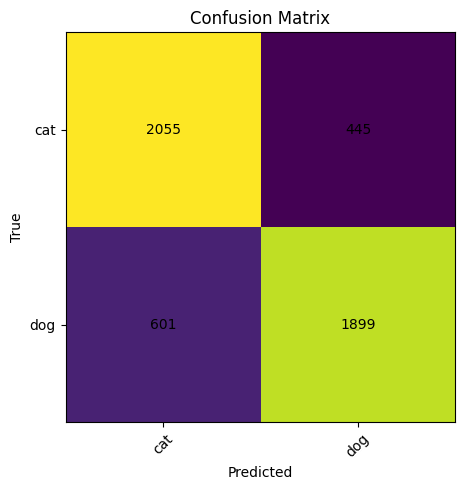

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predicciones
probs = model.predict(test_data, verbose=1)
y_pred = np.argmax(probs, axis=1)

# Etiquetas reales
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

print("Clases:", class_names)
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot matriz
plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


In [43]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
from pathlib import Path

# Pon aquí la ruta a una imagen concreta:
img_path = Path("../data/raw/test/cat")  # carpeta
# elige una imagen dentro de esa carpeta:
img_file = sorted(img_path.glob("*.jpg"))[0]
print("Usando:", img_file)

IMG_SIZE = (model.input_shape[1], model.input_shape[2])

img = load_img(img_file, target_size=IMG_SIZE)
x = img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

probs = model.predict(x, verbose=0)[0]
idx = int(np.argmax(probs))

class_names = list(test_data.class_indices.keys())  # usa las mismas clases del test
print("Predicción:", class_names[idx], "| prob:", float(probs[idx]))


Usando: ../data/raw/test/cat/cat.100.jpg


Predicción: cat | prob: 0.806921660900116


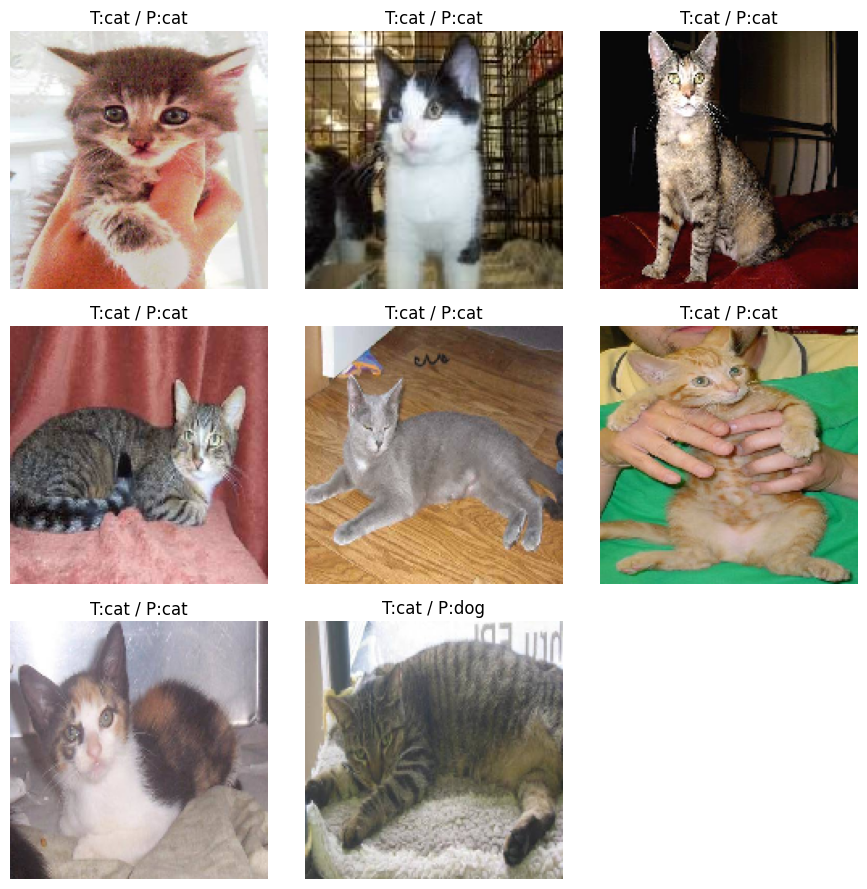

In [44]:
import matplotlib.pyplot as plt
import numpy as np

class_names = list(test_data.class_indices.keys())

batch_x, batch_y = next(test_data)
probs = model.predict(batch_x, verbose=0)
preds = np.argmax(probs, axis=1)
true = np.argmax(batch_y, axis=1)

n = min(9, batch_x.shape[0])   # si batch_size=8, n=8
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(9, 9))
for i in range(n):
    plt.subplot(rows, cols, i+1)
    plt.imshow(batch_x[i])
    plt.axis("off")
    plt.title(f"T:{class_names[true[i]]} / P:{class_names[preds[i]]}")
plt.tight_layout()
plt.show()


In [45]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

MODEL_PATH = Path("../models/best_model.keras")
TEST_DIR   = Path("../data/raw/test")

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

model = tf.keras.models.load_model(MODEL_PATH)

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


Found 5000 images belonging to 2 classes.


157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


In [46]:
import numpy as np

probs = model.predict(test_data, verbose=0)
preds = np.argmax(probs, axis=1)
true  = test_data.classes

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(true, preds)
print("Confusion matrix:\n", cm)

class_names = list(test_data.class_indices.keys())
print(classification_report(true, preds, target_names=class_names))


Confusion matrix:
 [[2055  445]
 [ 601 1899]]
              precision    recall  f1-score   support

         cat       0.77      0.82      0.80      2500
         dog       0.81      0.76      0.78      2500

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000



Se entrenó una red neuronal convolucional para clasificar imágenes de perros y gatos.
Las imágenes se reescalaron y redimensionaron a 160×160 píxeles para optimizar memoria.
El modelo se entrenó con datos de entrenamiento y validación y se evaluó en un conjunto de test independiente, obteniendo una accuracy aproximada del 79%.
El mejor modelo se guardó y se utilizó para evaluación y visualización de predicciones.